In [1]:
import os
import sys
from glob import glob

import zarr
import dask

# import xesmf as xe
import numpy as np
import xarray as xr

In [2]:
sys.path.insert(0, os.path.realpath("../libs/"))
import plevel_utils as pu

In [3]:
# import cmaps
# graph tools
import matplotlib.pyplot as plt

# import matplotlib.gridspec as gridspec
# import matplotlib.colors as colors
# import matplotlib.colorbar as cbar
# import matplotlib.ticker as ticker
# from matplotlib.ticker import ScalarFormatter
# from matplotlib.colors import LinearSegmentedColormap
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# import cartopy.crs as ccrs
# import cartopy.mpl.geoaxes
# import cartopy.feature as cfeature

%matplotlib inline

In [4]:
# import matplotlib.pyplot as plt
# %matplotlib inline

In [5]:
import time

## Variable info

In [6]:
GRAVITY = pu.GRAVITY

def wrf_destag(darray, stagger_dim):
    if stagger_dim not in darray.dims:
        raise ValueError(f"Dimension '{stagger_dim}' not found in input DataArray.")
    
    return 0.5 * (darray.isel({stagger_dim: slice(0, -1)}) +
                  darray.isel({stagger_dim: slice(1, None)}))

var_2d = [
    'ACDEWC', 'ACDRIPR', 'ACDRIPS', 'ACECAN', 'ACEDIR', 'ACETLSM',
    'ACETRAN', 'ACEVAC', 'ACEVB', 'ACEVC', 'ACEVG', 'ACFROC',
    'ACFRZC', 'ACGHB', 'ACGHFLSM', 'ACGHV', 'ACINTR', 'ACINTS',
    'ACIRB', 'ACIRC', 'ACIRG', 'ACLHFLSM', 'ACLWDNB', 'ACLWDNBC',
    'ACLWDNLSM', 'ACLWDNT', 'ACLWDNTC', 'ACLWUPB', 'ACLWUPBC', 'ACLWUPLSM',
    'ACLWUPT', 'ACLWUPTC', 'ACMELTC', 'ACPAHB', 'ACPAHG', 'ACPAHLSM',
    'ACPAHV', 'ACPONDING', 'ACQLAT', 'ACQRF', 'ACRAINLSM', 'ACRAINSNOW',
    'ACRUNSB', 'ACRUNSF', 'ACSAGB', 'ACSAGV', 'ACSAV', 'ACSHB',
    'ACSHC', 'ACSHFLSM', 'ACSHG', 'ACSNBOT', 'ACSNFRO', 'ACSNOM',
    'ACSNOWLSM', 'ACSNSUB', 'ACSUBC', 'ACSWDNB', 'ACSWDNBC', 'ACSWDNLSM',
    'ACSWDNT', 'ACSWDNTC', 'ACSWUPB', 'ACSWUPBC', 'ACSWUPLSM', 'ACSWUPT',
    'ACSWUPTC', 'ACTHROR', 'ACTHROS', 'ACTR', 'ALBEDO', 'CANICE',
    'CANWAT', 'COSZEN', 'EMISS', 'FORCPLSM', 'FORCQLSM', 'FORCTLSM',
    'FORCWLSM', 'FORCZLSM', 'GLW', 'GRAUPEL_ACC_NC', 'HFX', 'I_ACLWDNB',
    'I_ACLWDNBC', 'I_ACLWDNT', 'I_ACLWDNTC', 'I_ACLWUPB', 'I_ACLWUPBC', 'I_ACLWUPT',
    'I_ACLWUPTC', 'I_ACSWDNB', 'I_ACSWDNBC', 'I_ACSWDNT', 'I_ACSWDNTC', 'I_ACSWUPB',
    'I_ACSWUPBC', 'I_ACSWUPT', 'I_ACSWUPTC', 'LAI', 'LH', 'LWDNB',
    'LWDNBC', 'LWDNT', 'LWDNTC', 'LWUPB', 'LWUPBC', 'LWUPT',
    'LWUPTC', 'MLCAPE', 'MLCINH', 'MLLCL', 'MU', 'MUCAPE',
    'MUCINH', 'OLR', 'P', 'PBLH', 'PREC_ACC_NC', 'PSFC',
    'PWAT', 'Q2', 'QFX', 'QRFS', 'QSLAT', 'QSPRINGS',
    'QVAPOR', 'RAINNCV', 'RECH', 'REFL_10CM', 'REFL_1KM_AGL', 'REFL_COM',
    'SBCAPE', 'SBCINH', 'SBLCL', 'SEAICE', 'SH2O', 'SMCWTD',
    'SMOIS', 'SNICE', 'SNLIQ', 'SNOW', 'SNOWC', 'SNOWENERGY',
    'SNOWH', 'SNOW_ACC_NC', 'SOILENERGY', 'SR', 'SRH01', 'SRH03',
    'SST', 'SSTSK', 'SWDNB', 'SWDNBC', 'SWDNT', 'SWDNTC',
    'SWDOWN', 'SWNORM', 'SWUPB', 'SWUPBC', 'SWUPT', 'SWUPTC',
    'T2', 'TD2', 'TG', 'TH2', 'TK', 'TRAD',
    'TSK', 'TSLB', 'TSNO', 'TV', 'Times', 'U',
    'U10', 'USHR1', 'USHR6', 'UST', 'U_BUNK', 'V',
    'V10', 'VSHR1', 'VSHR6', 'V_BUNK', 'W', 'Z',
    'ZSNSO', 'ZWT', 'totalIce', 'totalLiq', 'totalVap',
    'index_snow_layers_stag', 'index_snso_layers_stag', 'index_soil_layers_stag'
]

var_3d = [
    'CLDFRA', 'O3RAD', 'P', 'P_HYD', 'QCLOUD',
    'QGRAUP', 'QICE', 'QNICE', 'QNRAIN', 'QRAIN',
    'QSNOW', 'QVAPOR', 'REFL_10CM', 'TK', 'Times',
    'U', 'V', 'W', 'Z', 'ilev', 'lev'
]

var_2d_pick = ['SMOIS', 'TSLB']
var_2d_drop = list(set(var_2d) - set(var_2d_pick))


In [7]:
# level_pick = [0, 6, 9, 12, 15, 18, 21, 24, 30, 36, 42, 48]
level_pick = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 21, 24, 30, 36, 42, 49]

## Native model level main loop

In [8]:
domain_inds = np.arange(336).astype(np.float32)
level_inds = np.arange(len(level_pick)).astype(np.float32)

pressure = np.array(
    [1000, 960, 940, 920, 880, 850, 800, 750, 680, 610, 500, 420, 280, 180, 100, 50]
).astype(np.float32)

In [9]:
fn_2d_full = sorted(glob('/glade/campaign/collections/rda/data/d559000/wy*/*/wrf2d*'))
ind_start = 50
ind_end = 51

fn_2d_subset = fn_2d_full[ind_start:ind_end]
L = len(fn_2d_subset)

for i in range(L):
    start_time = time.time()    
    fn_2d = fn_2d_subset[i]
    fn_3d = fn_2d[:62] + '3d' + fn_2d[64:]
    
    ds_2d = xr.open_dataset(fn_2d, drop_variables=var_2d_drop)
    ds_2d = ds_2d.drop_vars(['XLAT_U', 'XLONG_U', 'XLAT_V', 'XLONG_V'])
    
    ds_mlevel = ds_2d
    ds_mlevel = ds_mlevel.isel(west_east=slice(570, 905+1, 1), south_north=slice(200, 535+1, 1))
    ds_mlevel = ds_mlevel.map(lambda x: x.astype(np.float32) if x.dtype == np.float64 else x)
    
    #ds_mlevel = ds_mlevel.isel(bottom_top=level_pick)
    ds_mlevel = ds_mlevel.rename({'Time': 'time'})
    ds_mlevel = ds_mlevel.rename({'SMOIS': 'WRF_SMOIS', 'TSLB': 'WRF_TSLB'})
    ds_mlevel = ds_mlevel.isel(soil_layers_stag=0)
    ds_mlevel = ds_mlevel.reset_coords(drop=True)
    ds_mlevel = ds_mlevel.assign_coords(
        south_north=domain_inds, 
        west_east=domain_inds, 
        bottom_top=level_inds,
        pressure_approx=pressure
    )
    
    # -------------------------------------------------------- #
    if i == 0:
        varnames = list(ds_mlevel.keys())
        # zarr encodings
        dict_encoding = {}
        
        chunk_size_3d = dict(chunks=(1, 336, 336))
        #chunk_size_4d = dict(chunks=(1, 16, 336, 336))
        
        compress = zarr.Blosc(cname='zstd', clevel=1, shuffle=zarr.Blosc.SHUFFLE, blocksize=0)
        
        for i_var, var in enumerate(varnames):
            # if var in varname_4d:
            #     dict_encoding[var] = {'compressor': compress, **chunk_size_4d}
            # else:
            dict_encoding[var] = {'compressor': compress, **chunk_size_3d}
    
    save_name = '/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_GP/raw_404_L_extra/' + 'C404_GP_' + fn_2d[-22:-9] + 'H_Q_extra.zarr'
    print(save_name)
    #ds_mlevel.to_zarr(save_name, mode='w', consolidated=True, compute=True, encoding=dict_encoding)
    #print("--- %s seconds ---" % (time.time() - start_time))

/glade/campaign/ral/hap/ksha/DWC_data/CONUS_domain_GP/raw_404_L_extra/C404_GP_1979-10-03_02H_Q_extra.zarr
--- 3.591289758682251 seconds ---


In [23]:
SMOIS = ds_mlevel['SMOIS'].values
TSLB = ds_mlevel['TSLB'].values

In [24]:
T2 = ds_mlevel['T2'].values

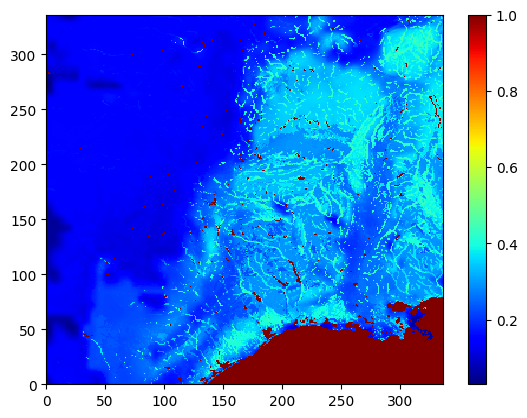

In [17]:
plt.pcolormesh(SMOIS[0, 0, ...], cmap=plt.cm.jet)
plt.colorbar()

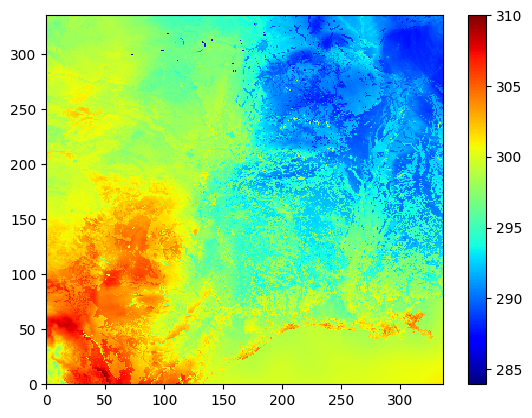

In [36]:
plt.pcolormesh(TSLB[0, 0, ...], cmap=plt.cm.jet)
plt.colorbar()

In [13]:
# dp = ds_mlevel['P'].diff(dim='bottom_top')
# var_mid = 0.5 * (ds_mlevel['WRF_Q_LC'].isel(bottom_top=slice(0, -1)) + ds_mlevel['WRF_Q_LC'].isel(bottom_top=slice(1, None)))

In [12]:
ds = xr.open_zarr(save_name)

In [13]:
ds

<xarray.Dataset>
Dimensions:          (time: 1, south_north: 336, west_east: 336,
                      bottom_top: 16, pressure_approx: 16)
Coordinates:
  * bottom_top       (bottom_top) float32 0.0 1.0 2.0 3.0 ... 13.0 14.0 15.0
  * pressure_approx  (pressure_approx) float32 1e+03 960.0 940.0 ... 100.0 50.0
  * south_north      (south_north) float32 0.0 1.0 2.0 3.0 ... 333.0 334.0 335.0
  * time             (time) datetime64[ns] 1979-10-03T02:00:00
  * west_east        (west_east) float32 0.0 1.0 2.0 3.0 ... 333.0 334.0 335.0
Data variables:
    WRF_IVT_U        (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_IVT_V        (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_PWAT_LC      (time, south_north, west_east) float32 dask.array<chunksize=(1, 336, 336), meta=np.ndarray>
    WRF_Q_LC         (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(1, 4, 168, 168), meta=np.ndarray>
    WRF_Q_tot        (time, bottom_top, south_north, west_east) float32 dask.array<chunksize=(1, 4, 168, 168), meta=np.ndarray>

In [20]:
import kornia.losses as losses

ModuleNotFoundError: No module named 'kornia'